In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
import pickle
import os
from torch_geometric.datasets import BA2MotifDataset
from torch.utils.data import Subset
from torch_geometric.data import Data
import networkx as ntx
from torch_geometric.utils import to_networkx,subgraph
import matplotlib.pyplot as plt

c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_spline_conv\_version_cpu.pyd
  import torch_geometric.typing
c:

In [4]:
class GINGraphClf(nn.Module):
    def __init__(self, in_dim,out_dim, hidden_dim=64):
        super().__init__()
        self.conv1=GINConv(nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(),nn.BatchNorm1d(hidden_dim), nn.Linear(hidden_dim, hidden_dim),nn.ReLU()))
        self.conv2=GINConv(nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),nn.BatchNorm1d(hidden_dim), nn.Linear(hidden_dim, hidden_dim),nn.ReLU()))
        self.conv3=GINConv(nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),nn.BatchNorm1d(hidden_dim), nn.Linear(hidden_dim, hidden_dim),nn.ReLU()))
        
        self.mlp = nn.Sequential(
            nn.Linear(3*hidden_dim, hidden_dim//2),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, out_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x, edge_index, batch):
        h1=self.conv1(x, edge_index)
        h2=self.conv2(h1, edge_index)
        h3=self.conv3(h2, edge_index)

        h1=global_add_pool(h1,batch)
        h2=global_add_pool(h2,batch)
        h3=global_add_pool(h3,batch)    


        x=torch.cat([h1,h2,h3],dim=1)


        return self.mlp(x)

In [5]:
dataset_path='./data/BA2Motif'
with open('./data/splits.pkl', 'rb') as f:
    splits=pickle.load(f)

full_dataset=BA2MotifDataset(root=dataset_path)
test_dataset=Subset(full_dataset,splits['test'])


test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=GINGraphClf(test_dataset[0].num_features,2).to(device)


checkpoint=torch.load('./models/GIN/best_gin_model.pt',map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [7]:
model.eval()
for param in model.parameters():
    param.requires_grad = False

print(f"Model loaded from './models/best_gcn_model.pt'")
print(f"Best validation accuracy during training: {checkpoint['best_val_acc']:.4f}")

Model loaded from './models/best_gcn_model.pt'
Best validation accuracy during training: 1.0000


In [8]:
def remove_node(data, nodes_to_remove):
    """
    حذف گره‌های مشخص شده از گراف و بازگرداندن گراف جدید (بدون تغییر در گراف اصلی).
    """
    if isinstance(nodes_to_remove, list):
        nodes_to_remove = torch.tensor(nodes_to_remove, dtype=torch.long)
    num_nodes = data.num_nodes
    keep_mask = torch.ones(num_nodes, dtype=torch.bool)
    keep_mask[nodes_to_remove] = False
    new_x = data.x[keep_mask]
    
    # نگاشت ایندکس
    new_index = torch.zeros(num_nodes, dtype=torch.long)
    new_index[keep_mask] = torch.arange(keep_mask.sum().item())
    
    edge_index = data.edge_index
    edge_mask = keep_mask[edge_index[0]] & keep_mask[edge_index[1]]
    new_edge_index = edge_index[:, edge_mask]
    new_edge_index = new_index[new_edge_index]
    
    new_data = Data(x=new_x, edge_index=new_edge_index)
    
    # کپی سایر ویژگی‌ها (مانند y, motif_mask و ...)
    for key in data.keys():   # توجه: پرانتز بعد از keys لازم است
        if key in ['x', 'edge_index', 'num_nodes']:
            continue
        attr = data[key]
        if torch.is_tensor(attr) and attr.size(0) == num_nodes:
            # ویژگی سطح گره
            new_data[key] = attr[keep_mask]
        else:
            # ویژگی سطح گراف (مثل y)
            new_data[key] = attr
    return new_data

In [9]:
def subgraph_connection_check(graph,node_set):
    if len(node_set) <= 1:
        return True
    sub_edge_index, _ = subgraph(node_set, graph.edge_index, relabel_nodes=True)
    # ساختن یک Data موقت برای تبدیل به networkx
    sub_data = Data(edge_index=sub_edge_index, num_nodes=len(node_set))
    G = to_networkx(sub_data, to_undirected=True)
    return ntx.is_connected(G)

In [10]:
def compute_score(model,data,target_class,device):
    model.eval()
    with torch.no_grad():
        if data.batch is not None:
            out=model(data.x,data.edge_index,data.batch)
        else:
            batch=torch.zeros(data.num_nodes,dtype=torch.long,device=device)
            out = model(data.x, data.edge_index, batch)
        if out.dim() == 1:
            out = out.unsqueeze(0)
        score = out[0, target_class]  
    return score 



In [11]:
def subgraph_explanation(model, data, target_class, budget=0.2, device=device, score_func='logit'):
    
    current_data = data.clone()

    current_nodes = set(range(data.num_nodes))
    removed_nodes = []
    
    initial_num_nodes = data.num_nodes
    target_size = budget if isinstance(budget, int) else int(initial_num_nodes * budget)
    target_size = max(1, min(target_size, initial_num_nodes))
    
    if isinstance(budget, float):
        target_size = max(1, int(initial_num_nodes * budget))
    
    print(f"شروع با {initial_num_nodes} گره، هدف نهایی: {target_size} گره")
    
    while len(current_nodes) > target_size:
        best_node = None
        best_delta = None
        best_new_data = None
        
        for v in list(current_nodes):
            candidate_nodes = current_nodes - {v}
            if not subgraph_connection_check(data, list(candidate_nodes)):
                continue  # حذف این گره باعث ناهمبندی می‌شود
            
            # ساخت زیرگراف فعلی (روی current_nodes)
            current_subgraph = remove_node(data, list(set(range(data.num_nodes)) - current_nodes))
            # ساخت زیرگراف کاندید (بدون v)
            candidate_subgraph = remove_node(data, list(set(range(data.num_nodes)) - candidate_nodes))
            
            # محاسبه امتیاز کلاس هدف برای هر دو
            score_current = compute_score(model, current_subgraph, target_class, device)
            score_candidate = compute_score(model, candidate_subgraph, target_class, device)
            
            delta = score_current - score_candidate
            
            if best_delta is None or delta < best_delta:
                best_delta = delta
                best_node = v
                best_new_data = candidate_subgraph
        
        if best_node is None:
            print("هیچ گره قابل حذفی یافت نشد (ممکن است گراف ناهمبند شود). توقف.")
            break
        
        # حذف بهترین گره
        current_nodes.remove(best_node)
        removed_nodes.append(best_node)
        # به‌روزرسانی current_data (اختیاری، برای محاسبات بعدی)
        current_data = best_new_data
        
        if len(current_nodes) % 10 == 0:
            print(f"گره‌های باقیمانده: {len(current_nodes)} / {initial_num_nodes}")
    
    # زیرگراف نهایی روی current_nodes
    final_subgraph = remove_node(data, list(set(range(data.num_nodes)) - current_nodes))
    print(f"توقف. زیرگراف نهایی با {final_subgraph.num_nodes} گره.")
    return final_subgraph, removed_nodes

In [12]:
correct_indices = []
wrong_indices = []

def evaluate(model, loader, device):
    global_idx=0
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            for i in range(len(pred)):
                if pred[i] == data.y[i]:
                    correct_indices.append(global_idx)
                else:
                    wrong_indices.append(global_idx)
            global_idx += 1
            correct += (pred == data.y).sum().item()
            total += data.num_graphs
            global_idx+=1
    return correct / total

test_acc = evaluate(model, test_loader, device)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Number of correct predictions: {len(correct_indices)}")

Test Accuracy: 1.0000
Number of correct predictions: 100


In [13]:
def visualize_explanation(original_data, explanation_node_indices, title="Explanation Subgraph", save_path=None):
    """
    نمایش گراف اصلی با هایلایت کردن گره‌هایی که در زیرگراف توضیح باقی مانده‌اند.
    
    Args:
        original_data: گراف اصلی (شیء Data) – شامل همه گره‌ها و یال‌ها
        explanation_node_indices: لیست ایندکس گره‌هایی که در زیرگراف توضیح هستند (همان گره‌های باقیمانده)
        title: عنوان نمودار
        save_path: مسیر ذخیره تصویر (اختیاری)
    """
    # تبدیل به شبکه NetworkX
    G = to_networkx(original_data, to_undirected=True)
    pos = ntx.spring_layout(G, seed=42)  # موقعیت ثابت برای تکرارپذیری
    
    # رنگ گره‌ها: قرمز برای گره‌های توضیح، آبی برای بقیه
    node_colors = []
    for node in G.nodes():
        if node in explanation_node_indices:
            node_colors.append('red')
        else:
            node_colors.append('skyblue')
    
    plt.figure(figsize=(10, 8))
    ntx.draw(G, pos, node_color=node_colors, with_labels=True, 
            node_size=500, font_size=10, font_weight='bold', 
            edge_color='gray', alpha=0.8)
    
    # اضافه کردن عنوان با تعداد گره‌ها
    plt.title(f"{title}\n(Explanation nodes: {len(explanation_node_indices)} / {original_data.num_nodes})")
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
# فرض کنید model و device و test_dataset آماده است
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# انتخاب یک گراف تست (مثلاً اولین گراف)
data = test_dataset[0].to(device)

# تعیین کلاس هدف (پیش‌بینی مدل)
with torch.no_grad():
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
    out = model(data.x, data.edge_index, batch)
    pred_class = out.argmax(dim=1).item()

budget = 0.2   # 20% گره‌ها
explanation_graph, removed = subgraph_explanation(
    model, data, target_class=pred_class, budget=budget, device=device
)

print(f"تعداد گره‌های توضیح: {explanation_graph.num_nodes}")
print(f"گره‌های حذف شده: {removed}")

شروع با 25 گره، هدف نهایی: 5 گره
گره‌های باقیمانده: 20 / 25
گره‌های باقیمانده: 10 / 25
توقف. زیرگراف نهایی با 5 گره.
تعداد گره‌های توضیح: 5
گره‌های حذف شده: [3, 4, 7, 5, 9, 10, 11, 8, 12, 13, 14, 15, 16, 6, 17, 18, 2, 19, 1, 0]


In [15]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

شروع با 25 گره، هدف نهایی: 5 گره
گره‌های باقیمانده: 20 / 25
گره‌های باقیمانده: 10 / 25
توقف. زیرگراف نهایی با 5 گره.
تعداد گره‌های توضیح: 5


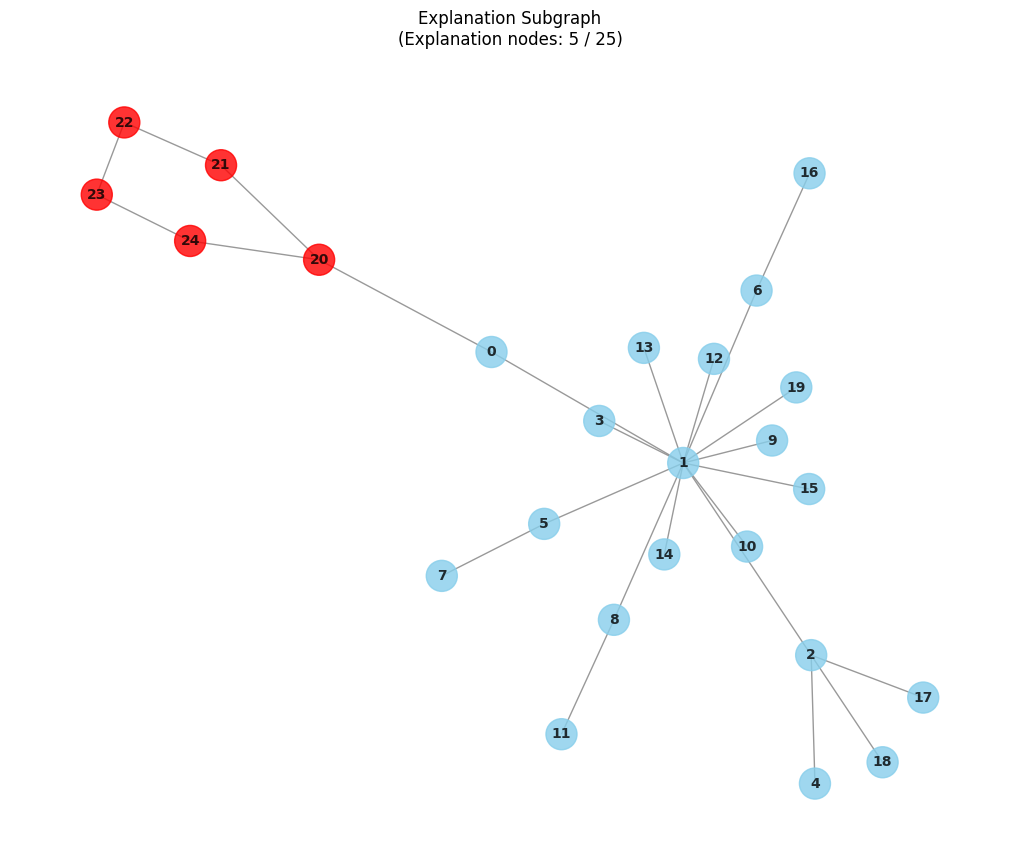

In [17]:
try:
    explanation_graph, removed_nodes = subgraph_explanation(
        model, data, target_class=pred_class, budget=0.2, device=device
    )
    all_nodes = set(range(data.num_nodes))
    remaining_nodes = list(all_nodes - set(removed_nodes))
    print(f"تعداد گره‌های توضیح: {len(remaining_nodes)}")
    # اختیاری: اگر می‌خواهید مصورسازی کنید
    visualize_explanation(data.cpu(), remaining_nodes)  # حتماً داده را به CPU ببرید
except Exception as e:
    print(f"خطا در اجرای الگوریتم: {e}")
    import traceback
    traceback.print_exc()